In [1]:
import torch
import numpy as np
import random

In [33]:
max_action = 10
dim = 4
A = np.random.rand(max_action, dim)
print(A.shape)

(10, 4)


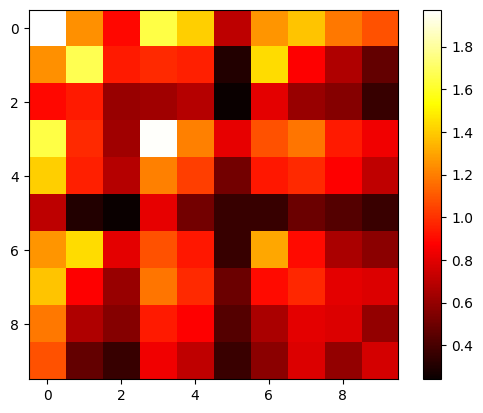

In [35]:
#plot the dot product
import matplotlib.pyplot as plt
plt.imshow(A.dot(A.T), cmap='hot',)
plt.colorbar()
#invert x axis
# plt.gca().invert_yaxis()
plt.show()

In [26]:
def wedge_product(u, v):
    wedge = np.outer(u, v) - np.outer(v, u)
    dim = u.shape[0]
    row_idx, col_idx = np.triu_indices(dim, k=1)
    bivector_components = wedge[row_idx, col_idx]
    return bivector_components

In [31]:
u = np.array([1, 2, 0, -1])
v = np.array([3, -1, 4, 2])
bivector = wedge_product(u, v)
print("Bivector Components:\n", bivector)

Bivector Components:
 [-7  4  5  8  3  4]


In [32]:
bivector = wedge_product(v, u)
print("Bivector Components:\n", bivector)

Bivector Components:
 [ 7 -4 -5 -8 -3 -4]


In [58]:
u = np.array([1,0, 0, 0])
v = np.array([0, -1, 0, 0])
bivector = wedge_product(u, v)
print("Bivector Components:\n", bivector)
print((bivector**2).sum())

Bivector Components:
 [-1  0  0  0  0  0]
1


In [57]:
#two orthagonal unit vectors should give the same bivector
u = np.random.rand(4)
u = u / np.linalg.norm(u)

#orthogonal to u
v = np.random.rand(4)
v = v - (v @ u) * u
v = v / np.linalg.norm(v)

bivector = wedge_product(u, v)
print("Bivector Components:\n", bivector)
print(bivector.sum())
print((bivector**2).sum())

Bivector Components:
 [-0.37359677 -0.07166519  0.58772614  0.23758434  0.48526193  0.46684267]
1.3321531051016975
1.0000000000000002


In [38]:
def pairwise_wedge(U, V):
    import numpy as np


    n, d = U.shape[0], U.shape[1]

    # Reshape for broadcasting: 
    # U becomes shape (10, 1, 4)
    # V becomes shape (1, 10, 4)
    U_expanded = U[:, np.newaxis, :]
    V_expanded = V[np.newaxis, :, :]

    # Compute the generalized outer product grid: shape (10, 10, 4, 4)
    # entry [i, j] gives the full matrix outer product of U[i] and V[j]
    outer_UV = U_expanded[:, :, :, np.newaxis] * V_expanded[:, :, np.newaxis, :]
    outer_VU = V_expanded[:, :, :, np.newaxis] * U_expanded[:, :, np.newaxis, :]

    # Subtract to get the antisymmetric wedge product matrix grid
    pairwise_wedge_matrices = outer_UV - outer_VU
    # Get the upper triangle indices for a d x d matrix
    row_idx, col_idx = np.triu_indices(d, k=1)

    # Slice the last two dimensions to extract the independent planes
    pairwise_bivectors = pairwise_wedge_matrices[:, :, row_idx, col_idx]

    print("Unique Component Grid Shape:", pairwise_bivectors.shape)
    # Output: (10, 10, 6)

    
    return pairwise_bivectors

In [ ]:
U = np.random.rand(max_action, dim)
V = np.random.rand(max_action, dim)

#normal each vector to unit length
U = U / np.linalg.norm(U, axis=1, keepdims=True)
V = V / np.linalg.norm(V, axis=1, keepdims=True)


array([[0.46787959, 0.47031918, 0.69626082, 0.274061  ],
       [0.32950489, 0.62105452, 0.60190833, 0.37871383],
       [0.23390394, 0.08524537, 0.0921043 , 0.96412601],
       [0.69747306, 0.47961972, 0.26035832, 0.46444569],
       [0.06428561, 0.21322963, 0.74492071, 0.62888284],
       [0.59137976, 0.29202688, 0.49858758, 0.56249507],
       [0.31612925, 0.85095766, 0.07108276, 0.41337707],
       [0.03984449, 0.62467869, 0.48765523, 0.60858963],
       [0.62846252, 0.54355905, 0.55638918, 0.00308317],
       [0.58171715, 0.11575957, 0.58552716, 0.55259644]])

In [44]:
pairwise_bivectors = pairwise_wedge(U, U)
pairwise_bivectors.shape

Unique Component Grid Shape: (10, 10, 6)


(10, 10, 6)

In [45]:
print(pairwise_bivectors[0, 1 , :])
print(pairwise_bivectors[1, 0 , :])

[ 0.13560627  0.05219928  0.08688804 -0.1493269   0.00790956  0.09872401]
[-0.13560627 -0.05219928 -0.08688804  0.1493269  -0.00790956 -0.09872401]


Sum of Unique Components Shape: (10, 10)


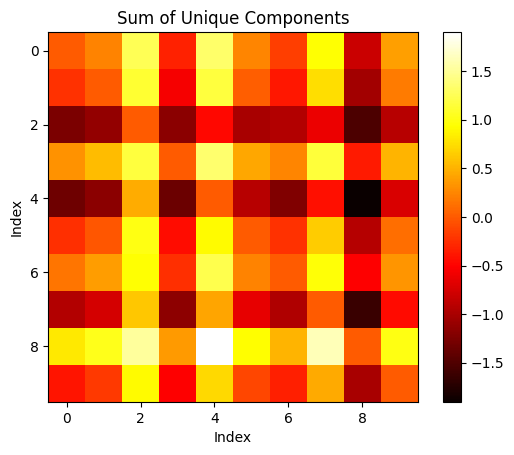

In [46]:
out = pairwise_bivectors.sum(axis=-1)
print("Sum of Unique Components Shape:", out.shape)


#Plot heatmap of out 
import matplotlib.pyplot as plt

plt.imshow(out, cmap='hot')
plt.colorbar()
plt.title('Sum of Unique Components')
plt.xlabel('Index')
plt.ylabel('Index')
plt.show()


In [25]:
out[0, 0], out[-1, -1] 

(np.float64(0.9718080805865021), np.float64(2.0324525175646317))

In [36]:
pairwise_bivectors[0, 0 , :]

array([ 0.77395053,  0.48435013,  0.6986629 , -0.28045134, -0.58916531,
       -0.11553884])

In [48]:
out.max(), out.min()

(np.float64(1.901535972134563), np.float64(-1.901535972134563))

In [37]:
print(pairwise_bivectors[0, 1 , :])
print(pairwise_bivectors[1, 0 , :])

[ 0.57370349  0.02113284  0.72138299 -0.25588209 -0.40782642  0.30672719]
[ 0.27392967  0.18232188  0.25138974  0.15621233 -0.11219768 -0.21803505]
